# Tech Challenge — Previsão da direção do IBOVESPA no dia seguinte

## Objetivo
Desenvolver um modelo preditivo capaz de prever se o **fechamento do IBOVESPA no dia seguinte** será **maior (↑)** ou **menor (↓)** que o fechamento do dia atual, utilizando **apenas o histórico do próprio índice**.

## O que este notebook entrega
Este notebook foi estruturado como uma entrega técnica completa, cobrindo:

1. **Aquisição e exploração dos dados**
2. **Pré-processamento do CSV baixado no Investing**
3. **Engenharia de atributos**
4. **Definição correta do target**
5. **Tratamento da natureza temporal da série**
6. **Treinamento, validação e teste**
7. **Comparação entre modelos**
8. **Análise de métricas e risco de overfitting**
9. **Justificativa técnica da abordagem**

## Fonte dos dados
Histórico diário do índice IBOVESPA disponível em:
- Investing.com: `https://br.investing.com/indices/bovespa-historical-data`

> **Observação importante**  
> O problema exige que o conjunto de teste contenha os **últimos 30 dias disponíveis**.  
> Por isso, todo o fluxo deste notebook respeita a ordem temporal dos dados e **não embaralha a série**.

## Estratégia adotada

Como estamos lidando com uma **série temporal financeira**, a principal preocupação não é apenas treinar um modelo com boa acurácia, mas fazer isso de forma **estatisticamente coerente**, evitando vazamento de informação.

### Decisões centrais deste notebook
- O target será definido como:

  \[
  y_t = 
  egin{cases}
  1, & 	ext{se } fechamento_{t+1} > fechamento_t \
  0, & 	ext{caso contrário}
  \end{cases}
  \]

- O conjunto de teste será composto pelos **últimos 30 pregões**
- Será criada também uma **janela de validação temporal** imediatamente anterior ao teste
- A engenharia de atributos será feita usando **apenas informações disponíveis até o dia t**:
  - retornos passados
  - volatilidade
  - distâncias para médias móveis
  - momentum
  - posição do fechamento dentro do candle
  - indicadores técnicos derivados apenas do preço
- Serão comparados modelos adequados para tabular/séries com baixo volume:
  - Regressão Logística
  - Random Forest
  - HistGradientBoosting

### Por que não começar com LSTM?
Embora redes neurais recorrentes sejam populares em séries temporais, neste problema elas **não são necessariamente a melhor escolha**:
- temos uma base relativamente pequena para deep learning
- o sinal preditivo em mercado financeiro diário costuma ser fraco
- o risco de overfitting é alto
- modelos tabulares bem validados costumam ser uma base mais forte e mais defensável tecnicamente

Ou seja: a escolha aqui prioriza **robustez, interpretabilidade e controle de overfitting**.

In [4]:
# ============================================================
# 1. Imports e configurações iniciais
# ============================================================

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

RANDOM_STATE = 42
TEST_SIZE = 30      # exigência do desafio
VALID_SIZE = 60     # janela de validação temporal antes do teste

# Ajuste aqui o nome/caminho do CSV, se necessário
CSV_PATH = Path("../data/raw/Dados Históricos - Ibovespa.csv")

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## Leitura e limpeza do arquivo

O CSV exportado do Investing normalmente vem com colunas como:

- `Data`
- `Último`
- `Abertura`
- `Máxima`
- `Mínima`
- `Vol.`
- `Var%`

Além disso, há dois cuidados importantes:

1. **Números em formato pt-BR**  
   Ex.: `182.369`, `5,18M`, `+0,45%`

2. **Ordem dos registros**  
   O arquivo geralmente vem em ordem **decrescente** de data, mas para séries temporais precisamos trabalhar em ordem **crescente**.

In [5]:
# ============================================================
# 2. Funções auxiliares de parsing e limpeza
# ============================================================

def find_csv_file(preferred_path: Path) -> Path:
    """
    Localiza o CSV. Primeiro tenta o caminho informado.
    Se não encontrar, busca automaticamente por outros CSVs no diretório atual.
    """
    if preferred_path.exists():
        return preferred_path

    candidates = list(Path(".").rglob("*.csv"))
    if not candidates:
        raise FileNotFoundError(
            "Nenhum arquivo CSV foi encontrado. "
            "Verifique se o arquivo foi salvo na pasta correta."
        )

    print("Arquivo informado não encontrado. CSVs encontrados no diretório:")
    for c in candidates:
        print(" -", c)
    return candidates[0]


def parse_ptbr_number(value):
    """
    Converte números em formato brasileiro para float.
    Exemplos:
    - '182.369' -> 182369.0
    - '0,45'    -> 0.45
    - '-'       -> NaN
    """
    if pd.isna(value):
        return np.nan

    s = str(value).strip()
    if s in {"", "-", "nan", "None"}:
        return np.nan

    s = s.replace(".", "").replace(",", ".")

    try:
        return float(s)
    except ValueError:
        return np.nan


def parse_volume(value):
    """
    Converte volume textual para float.
    Exemplos:
    - '5,18M'   -> 5_180_000
    - '8,07B'   -> 8_070_000_000
    - '192,99K' -> 192_990
    - '-'       -> NaN
    """
    if pd.isna(value):
        return np.nan

    s = str(value).strip().upper()
    if s in {"", "-", "NAN", "NONE"}:
        return np.nan

    s = s.replace(".", "").replace(",", ".")

    multipliers = {"K": 1e3, "M": 1e6, "B": 1e9}

    suffix = s[-1]
    if suffix in multipliers:
        number = s[:-1]
        try:
            return float(number) * multipliers[suffix]
        except ValueError:
            return np.nan

    try:
        return float(s)
    except ValueError:
        return np.nan


def load_ibov_csv(csv_path: Path) -> pd.DataFrame:
    """
    Carrega o CSV do Investing e devolve um DataFrame limpo,
    em ordem crescente de data, pronto para análise.
    """
    csv_path = find_csv_file(csv_path)
    print(f"Usando arquivo: {csv_path}")

    # sep=None tenta detectar automaticamente vírgula/; etc
    df = pd.read_csv(csv_path, sep=None, engine="python", encoding="utf-8-sig")

    rename_map = {
        "Data": "data",
        "Date": "data",
        "Último": "fechamento",
        "Último*": "fechamento",
        "Price": "fechamento",
        "Abertura": "abertura",
        "Open": "abertura",
        "Máxima": "maxima",
        "High": "maxima",
        "Mínima": "minima",
        "Low": "minima",
        "Vol.": "volume",
        "Vol": "volume",
        "Volume": "volume",
        "Var%": "variacao_pct",
        "Change %": "variacao_pct",
    }

    df = df.rename(columns=rename_map)

    required_cols = ["data", "fechamento", "abertura", "maxima", "minima", "volume", "variacao_pct"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(
            f"As seguintes colunas obrigatórias não foram encontradas no CSV: {missing}\n"
            f"Colunas disponíveis: {list(df.columns)}"
        )

    df = df[required_cols].copy()

    df["data"] = pd.to_datetime(df["data"], format="%d.%m.%Y", errors="coerce")
    if df["data"].isna().any():
        df["data"] = pd.to_datetime(df["data"], errors="coerce", dayfirst=True)

    for col in ["fechamento", "abertura", "maxima", "minima"]:
        df[col] = df[col].apply(parse_ptbr_number)

    df["volume"] = df["volume"].apply(parse_volume)

    df["variacao_pct"] = (
        df["variacao_pct"]
        .astype(str)
        .str.replace("%", "", regex=False)
        .apply(parse_ptbr_number)
        / 100
    )

    df = df.sort_values("data").reset_index(drop=True)
    df = df.dropna(subset=["data", "fechamento", "abertura", "maxima", "minima"]).copy()
    df = df.drop_duplicates(subset="data", keep="last").reset_index(drop=True)

    return df


df = load_ibov_csv(CSV_PATH)
df.head()

Usando arquivo: ../data/raw/Dados Históricos - Ibovespa.csv


,data,fechamento,abertura,maxima,minima,volume,variacao_pct
0,2006-01-02,"33,507.0000","33,462.0000","33,519.0000","3,286.0000","72,320,000.0000",0.0015
1,2006-01-03,"34,541.0000","33,507.0000","34,563.0000","33,507.0000","148,380,000.0000",0.0309
2,2006-01-04,"35,002.0000","3,454.0000","35,223.0000","3,454.0000","147,130,000.0000",0.0133
3,2006-01-05,"34,936.0000","35,006.0000","35,088.0000","34,681.0000","142,070,000.0000",-0.0019
4,2006-01-06,"35,475.0000","3,517.0000","35,529.0000","3,494.0000","115,090,000.0000",0.0154


In [6]:
# Visão geral da base
print("Formato da base:", df.shape)
print("\nPeríodo coberto:")
print(df["data"].min().date(), "->", df["data"].max().date())

print("\nTipos das colunas:")
display(df.dtypes)

print("\nValores ausentes por coluna:")
display(df.isna().sum())

display(df.head(3))
display(df.tail(3))

Formato da base: (5000, 7)

Período coberto:
2006-01-02 -> 2026-03-10

Tipos das colunas:


data            datetime64[us]
fechamento             float64
abertura               float64
maxima                 float64
minima                 float64
volume                 float64
variacao_pct           float64
dtype: object


Valores ausentes por coluna:


data            0
fechamento      0
abertura        0
maxima          0
minima          0
volume          1
variacao_pct    0
dtype: int64

,data,fechamento,abertura,maxima,minima,volume,variacao_pct
0,2006-01-02,"33,507.0000","33,462.0000","33,519.0000","3,286.0000","72,320,000.0000",0.0015
1,2006-01-03,"34,541.0000","33,507.0000","34,563.0000","33,507.0000","148,380,000.0000",0.0309
2,2006-01-04,"35,002.0000","3,454.0000","35,223.0000","3,454.0000","147,130,000.0000",0.0133


,data,fechamento,abertura,maxima,minima,volume,variacao_pct
4997,2026-03-06,"179,365.0000","180,463.0000","181,091.0000","178,556.0000","9,920,000,000.0000",-0.0061
4998,2026-03-09,"180,915.0000","179,367.0000","181,952.0000","177,637.0000","11,420,000,000.0000",0.0086
4999,2026-03-10,"183,447.0000","180,921.0000","185,324.0000","180,693.0000","10,080,000,000.0000",0.0140


## Sanidade da base

Antes de seguir, vamos validar alguns pontos que costumam gerar erro em trabalhos desse tipo:

- a data está em ordem crescente?
- existem duplicidades?
- o período mínimo exigido (2 anos) foi atendido?

In [7]:
# ============================================================
# 3. Sanity checks
# ============================================================

assert df["data"].is_monotonic_increasing, "A base não está em ordem crescente de data."
assert df["data"].duplicated().sum() == 0, "Existem datas duplicadas na base."

period_days = (df["data"].max() - df["data"].min()).days
period_years = period_days / 365.25

print(f"Janela histórica disponível: {period_years:.2f} anos")

if period_years < 2:
    raise ValueError("O desafio exige pelo menos 2 anos de dados.")

print("Sanity checks concluídos com sucesso.")

Janela histórica disponível: 20.18 anos
Sanity checks concluídos com sucesso.


# 4. Análise exploratória

Nesta etapa vamos responder perguntas básicas, mas importantes:

- qual é a evolução do índice no período?
- qual é a distribuição dos retornos diários?
- existe algum desbalanceamento muito forte entre dias de alta e baixa?

Isso é importante porque, se as classes estiverem muito desequilibradas, uma acurácia aparentemente alta pode ser enganosa.

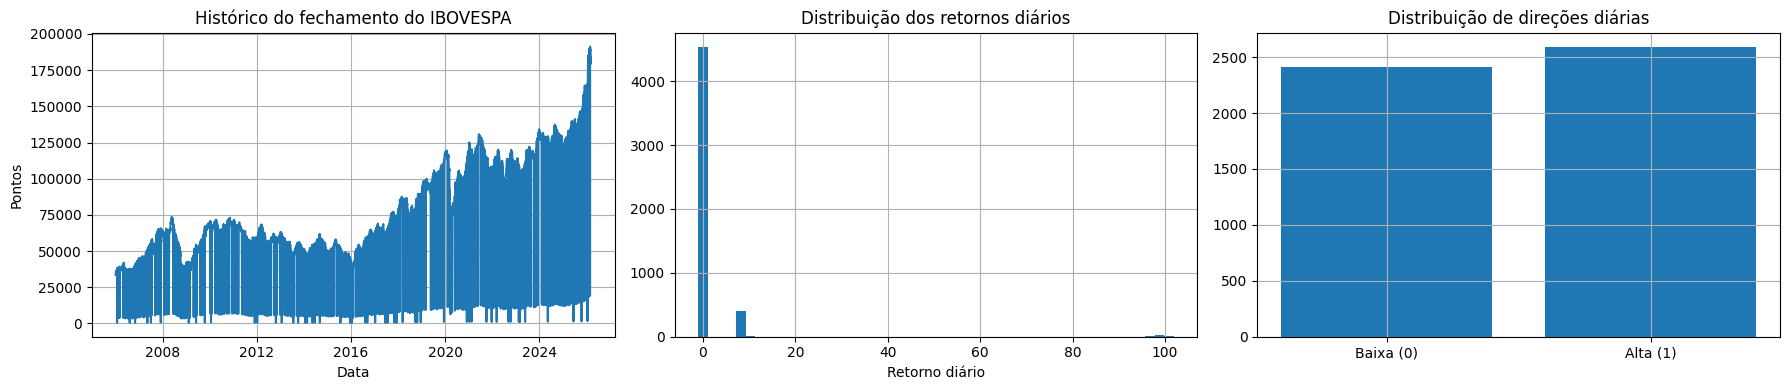

Estatísticas descritivas dos retornos diários:


count   4,999.0000
mean        1.6051
std         9.8284
min        -0.9904
1%         -0.9051
5%         -0.9000
50%         0.0008
95%         9.0028
99%         9.6599
max       101.8481
Name: retorno_1d, dtype: float64

In [8]:
# ============================================================
# 4. EDA
# ============================================================

df_eda = df.copy()
df_eda["retorno_1d"] = df_eda["fechamento"].pct_change()
df_eda["direcao_d1"] = (df_eda["retorno_1d"] > 0).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(df_eda["data"], df_eda["fechamento"])
axes[0].set_title("Histórico do fechamento do IBOVESPA")
axes[0].set_xlabel("Data")
axes[0].set_ylabel("Pontos")

axes[1].hist(df_eda["retorno_1d"].dropna(), bins=50)
axes[1].set_title("Distribuição dos retornos diários")
axes[1].set_xlabel("Retorno diário")

class_counts = df_eda["direcao_d1"].value_counts().sort_index()
axes[2].bar(["Baixa (0)", "Alta (1)"], class_counts.values)
axes[2].set_title("Distribuição de direções diárias")

plt.tight_layout()
plt.show()

print("Estatísticas descritivas dos retornos diários:")
display(df_eda["retorno_1d"].describe(percentiles=[0.01, 0.05, 0.50, 0.95, 0.99]))

# 5. Engenharia de atributos

Como o problema pede previsão do **dia seguinte**, precisamos transformar a série bruta em variáveis que capturem o comportamento recente do índice.

## Atributos construídos

### Retornos e momentum
- retorno de 1, 2, 3, 5, 10 e 20 dias
- momentum acumulado

### Tendência
- distância do fechamento para médias móveis
- MACD
- posição em bandas de Bollinger

### Risco / volatilidade
- volatilidade rolante
- amplitude do candle

### Microestrutura simples do candle
- corpo relativo
- gap de abertura
- posição do fechamento entre mínima e máxima do dia

### Sazonalidade
- dia da semana (one-hot)

## Cuidados contra vazamento
Todos os atributos são calculados usando apenas informação disponível até o instante t.  
Nenhum atributo usa informação de t+1 ou posterior.

In [9]:
# ============================================================
# 5. Engenharia de atributos
# ============================================================

def compute_rsi(series: pd.Series, window: int = 14) -> pd.Series:
    delta = series.diff()
    gains = delta.clip(lower=0)
    losses = -delta.clip(upper=0)

    avg_gain = gains.rolling(window).mean()
    avg_loss = losses.rolling(window).mean()

    rs = avg_gain / avg_loss.replace(0, np.nan)
    rsi = 100 - (100 / (1 + rs))
    return rsi


def build_features(df: pd.DataFrame) -> pd.DataFrame:
    data = df.copy()

    close = data["fechamento"]
    open_ = data["abertura"]
    high = data["maxima"]
    low = data["minima"]
    volume = data["volume"]

    # -------------------------
    # Retornos e momentum
    # -------------------------
    data["retorno_1d"] = close.pct_change(1)
    for lag in [2, 3, 5, 10, 20]:
        data[f"retorno_{lag}d"] = close.pct_change(lag)

    for window in [5, 10, 20]:
        data[f"dias_positivos_{window}d"] = data["retorno_1d"].gt(0).rolling(window).mean()

    # -------------------------
    # Candle / microestrutura
    # -------------------------
    candle_range = (high - low).replace(0, np.nan)
    data["amplitude_rel"] = (high - low) / close
    data["corpo_rel"] = (close - open_) / open_
    data["gap_abertura"] = open_ / close.shift(1) - 1
    data["posicao_fechamento"] = (close - low) / candle_range

    # -------------------------
    # Tendência / médias móveis
    # -------------------------
    for window in [5, 10, 20, 50, 100]:
        ma = close.rolling(window).mean()
        std = close.rolling(window).std()

        data[f"dist_mm_{window}"] = close / ma - 1

        if window == 20:
            data["zscore_preco_20"] = (close - ma) / std
            upper = ma + 2 * std
            lower = ma - 2 * std
            band_range = (upper - lower).replace(0, np.nan)
            data["bollinger_pos_20"] = (close - lower) / band_range

    # -------------------------
    # Volatilidade
    # -------------------------
    for window in [5, 10, 20, 30]:
        data[f"volatilidade_{window}d"] = data["retorno_1d"].rolling(window).std()

    # -------------------------
    # Indicadores técnicos simples
    # -------------------------
    ema12 = close.ewm(span=12, adjust=False).mean()
    ema26 = close.ewm(span=26, adjust=False).mean()
    macd_line = ema12 - ema26
    signal_line = macd_line.ewm(span=9, adjust=False).mean()

    data["macd_rel"] = macd_line / close
    data["macd_signal_rel"] = signal_line / close
    data["macd_hist_rel"] = (macd_line - signal_line) / close
    data["rsi_14"] = compute_rsi(close, window=14) / 100

    # -------------------------
    # Volume relativo
    # -------------------------
    for window in [5, 20]:
        vol_ma = volume.rolling(window).mean()
        vol_std = volume.rolling(window).std()

        data[f"volume_ratio_{window}d"] = volume / vol_ma
        data[f"volume_zscore_{window}d"] = (volume - vol_ma) / vol_std

    # -------------------------
    # Sazonalidade simples
    # -------------------------
    data["dia_semana"] = data["data"].dt.dayofweek
    dummies_dow = pd.get_dummies(data["dia_semana"], prefix="dow", drop_first=True, dtype=int)
    data = pd.concat([data, dummies_dow], axis=1)

    # -------------------------
    # Target: direção do próximo dia
    # -------------------------
    data["target"] = (data["fechamento"].shift(-1) > data["fechamento"]).astype(int)

    data = data.iloc[:-1].copy()
    data = data.dropna().reset_index(drop=True)

    return data


df_model = build_features(df)

print("Base original:", df.shape)
print("Base modelável após engenharia de atributos:", df_model.shape)

display(df_model.head())

Base original: (5000, 7)
Base modelável após engenharia de atributos: (4880, 45)


,data,fechamento,abertura,maxima,minima,volume,variacao_pct,retorno_1d,retorno_2d,retorno_3d,retorno_5d,retorno_10d,retorno_20d,dias_positivos_5d,dias_positivos_10d,dias_positivos_20d,amplitude_rel,corpo_rel,gap_abertura,posicao_fechamento,dist_mm_5,dist_mm_10,dist_mm_20,zscore_preco_20,bollinger_pos_20,dist_mm_50,dist_mm_100,volatilidade_5d,volatilidade_10d,volatilidade_20d,volatilidade_30d,macd_rel,macd_signal_rel,macd_hist_rel,rsi_14,volume_ratio_5d,volume_zscore_5d,volume_ratio_20d,volume_zscore_20d,dia_semana,dow_1,dow_2,dow_3,dow_4,target
0,2006-05-29,"38,145.0000","38,634.0000","38,734.0000","38,055.0000","32,600,000.0000",-0.0126,8.8744,0.0153,0.0657,0.0452,-0.0287,-0.0550,0.6000,0.4000,0.4500,0.0178,-0.0127,9.0010,0.1325,0.6030,0.2356,0.1189,0.3082,0.5771,0.0578,0.0750,5.2047,3.8631,3.3477,3.1433,-0.0706,-0.0395,-0.0311,0.4864,0.2117,-1.7175,0.2030,-1.9592,0,0,0,0,0,0
1,2006-05-30,"36,413.0000","38,149.0000","38,149.0000","36,413.0000","143,090,000.0000",-0.0454,-0.0454,8.4261,-0.0308,9.0839,-0.0762,-0.1122,0.6000,0.3000,0.4000,0.0477,-0.0455,0.0001,0.0000,0.1995,0.1911,0.0754,0.1954,0.5488,0.0107,0.0254,5.0475,3.8654,3.3488,3.1438,-0.0558,-0.0442,-0.0115,0.4812,1.0196,0.0437,0.8848,-0.2874,1,1,0,0,0,0
2,2006-05-31,"3,653.0000","36,414.0000","37,216.0000","36,362.0000","188,730,000.0000",0.0032,-0.8997,-0.9042,-0.0544,-0.8979,-0.9046,-0.1073,0.4000,0.3000,0.4000,0.2338,-0.8997,0.0000,-38.3009,-0.8473,-0.8652,-0.8920,-2.3006,-0.0752,-0.8966,-0.8962,4.1936,3.9154,3.3488,3.1587,-1.1227,-0.5773,-0.5455,0.3931,1.3506,0.7850,1.1414,0.3644,2,0,1,0,0,1
3,2006-06-01,"37,748.0000","36,531.0000","37,748.0000","36,502.0000","142,620,000.0000",0.0333,9.3334,0.0367,-0.0104,0.0048,-0.0016,-0.0788,0.4000,0.4000,0.4000,0.0330,0.0333,9.0003,1.0000,0.5752,0.3928,0.1209,0.3120,0.5780,0.0684,0.0715,5.3366,4.5732,3.3886,3.4952,-0.0783,-0.0604,-0.0180,0.4941,1.0426,0.0944,0.8602,-0.3625,3,0,0,1,0,1
4,2006-06-02,"37,942.0000","3,775.0000","38,437.0000","37,411.0000","180,040,000.0000",0.0051,0.0051,9.3865,0.0420,8.8219,0.0055,-0.0839,0.6000,0.5000,0.4000,0.0270,9.0509,-0.9000,0.5175,0.2327,0.3989,0.1325,0.3425,0.5856,0.0736,0.0760,5.1731,4.5728,3.3887,3.4953,-0.0530,-0.0586,0.0056,0.4968,1.3102,0.6848,1.0732,0.1926,4,0,0,0,1,0


In [10]:
# Seleção final de features
# Mantemos apenas atributos derivados e variáveis explicativas disponíveis em t

drop_cols = [
    "target",
    "data",
    "dia_semana",
    # preços absolutos ficam de fora para reduzir não estacionariedade
    "fechamento",
    "abertura",
    "maxima",
    "minima",
    "volume",
]

feature_cols = [c for c in df_model.columns if c not in drop_cols]

X = df_model[feature_cols].copy()
y = df_model["target"].copy()
dates = df_model["data"].copy()

print(f"Quantidade de features: {len(feature_cols)}")
display(feature_cols[:20])

Quantidade de features: 37


['variacao_pct',
 'retorno_1d',
 'retorno_2d',
 'retorno_3d',
 'retorno_5d',
 'retorno_10d',
 'retorno_20d',
 'dias_positivos_5d',
 'dias_positivos_10d',
 'dias_positivos_20d',
 'amplitude_rel',
 'corpo_rel',
 'gap_abertura',
 'posicao_fechamento',
 'dist_mm_5',
 'dist_mm_10',
 'dist_mm_20',
 'zscore_preco_20',
 'bollinger_pos_20',
 'dist_mm_50']

## Preparação da base para previsão

Aqui fazemos o split respeitando a cronologia:

- **Treino:** dados mais antigos
- **Validação:** janela imediatamente anterior ao teste
- **Teste:** **últimos 30 pregões** disponíveis, conforme exigido no desafio

Essa separação é importante para simular o cenário real de uso do modelo:  
treinar no passado e prever o futuro.

In [11]:
# ============================================================
# 6. Split temporal
# ============================================================

if len(df_model) <= TEST_SIZE + VALID_SIZE + 200:
    raise ValueError(
        "A base ficou pequena demais após a engenharia de atributos. "
        "Considere usar um intervalo maior de dados."
    )

X_train = X.iloc[: -(VALID_SIZE + TEST_SIZE)].copy()
y_train = y.iloc[: -(VALID_SIZE + TEST_SIZE)].copy()
dates_train = dates.iloc[: -(VALID_SIZE + TEST_SIZE)].copy()

X_valid = X.iloc[-(VALID_SIZE + TEST_SIZE):-TEST_SIZE].copy()
y_valid = y.iloc[-(VALID_SIZE + TEST_SIZE):-TEST_SIZE].copy()
dates_valid = dates.iloc[-(VALID_SIZE + TEST_SIZE):-TEST_SIZE].copy()

X_test = X.iloc[-TEST_SIZE:].copy()
y_test = y.iloc[-TEST_SIZE:].copy()
dates_test = dates.iloc[-TEST_SIZE:].copy()

print("Treino    :", X_train.shape, dates_train.min().date(), "->", dates_train.max().date())
print("Validação :", X_valid.shape, dates_valid.min().date(), "->", dates_valid.max().date())
print("Teste     :", X_test.shape, dates_test.min().date(), "->", dates_test.max().date())

Treino    : (4790, 37) 2006-05-29 -> 2025-10-23
Validação : (60, 37) 2025-10-24 -> 2026-01-22
Teste     : (30, 37) 2026-01-23 -> 2026-03-09


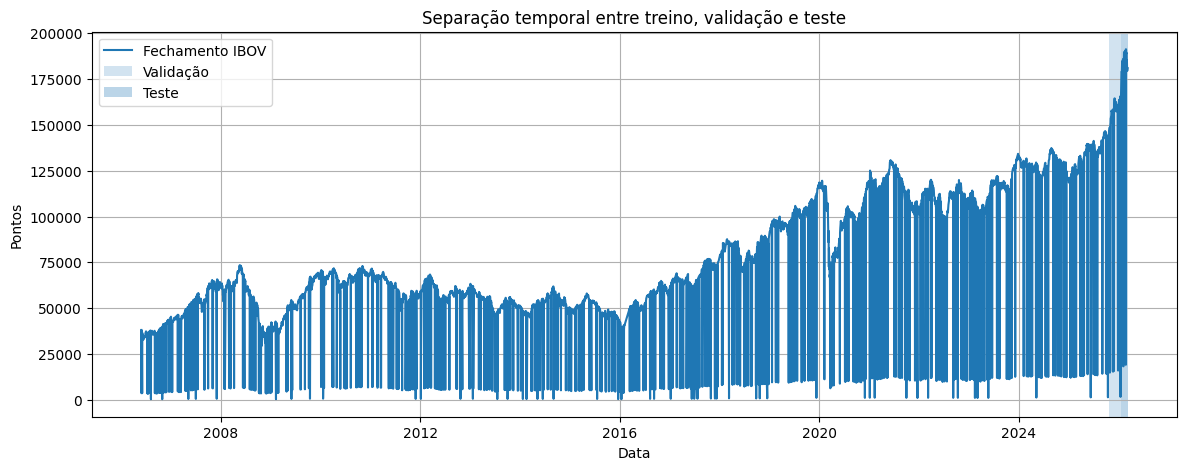

In [12]:
# Visualização do recorte temporal
plt.figure(figsize=(14, 5))
plt.plot(df_model["data"], df_model["fechamento"], label="Fechamento IBOV")
plt.axvspan(dates_valid.min(), dates_valid.max(), alpha=0.2, label="Validação")
plt.axvspan(dates_test.min(), dates_test.max(), alpha=0.3, label="Teste")
plt.title("Separação temporal entre treino, validação e teste")
plt.xlabel("Data")
plt.ylabel("Pontos")
plt.legend()
plt.show()

# 7. Baselines

Antes de buscar modelos mais sofisticados, vale comparar com referências simples:

1. **Baseline majoritária**  
   Sempre prever a classe mais frequente

2. **Baseline de persistência**  
   Prever que amanhã terá a mesma direção de hoje

Se o modelo não superar esses baselines de forma consistente, ele provavelmente não está agregando valor real.

In [13]:
# ============================================================
# 7. Baselines
# ============================================================

def evaluate_predictions(y_true, y_pred, label="Modelo"):
    return {
        "modelo": label,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

baseline_results = []

dummy_majority = DummyClassifier(strategy="most_frequent")
dummy_majority.fit(X_train, y_train)
valid_pred_majority = dummy_majority.predict(X_valid)
baseline_results.append(evaluate_predictions(y_valid, valid_pred_majority, "Dummy Most Frequent"))

valid_pred_persistence = (
    df_model.loc[X_valid.index, "retorno_1d"].gt(0).astype(int).values
)
baseline_results.append(evaluate_predictions(y_valid, valid_pred_persistence, "Persistência Direcional"))

baseline_df = pd.DataFrame(baseline_results).sort_values("accuracy", ascending=False)
display(baseline_df)

,modelo,accuracy,precision,recall,f1
0,Dummy Most Frequent,0.6333,0.6333,1.0000,0.7755
1,Persistência Direcional,0.5000,0.6053,0.6053,0.6053


# 8. Seleção de modelos e busca de hiperparâmetros

Nesta etapa usamos apenas a **base de treino** para ajuste de modelos e hiperparâmetros.  
A validação e o teste permanecem separados.

## Modelos avaliados
- **Regressão Logística**  
  Forte baseline para classificação binária, boa interpretabilidade e menor risco de overfitting

- **Random Forest**  
  Captura não linearidades e interações entre variáveis

- **HistGradientBoosting**  
  Modelo de boosting bastante competitivo em dados tabulares

## Validação no treino
Para respeitar a sequência temporal, usamos **TimeSeriesSplit** dentro da base de treino.

In [14]:
# ============================================================
# 8. Busca de hiperparâmetros com validação temporal
# ============================================================

tscv = TimeSeriesSplit(n_splits=5)

search_spaces = {
    "Logistic Regression": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))
        ]),
        {
            "model__C": [0.05, 0.1, 0.5, 1.0, 2.0],
            "model__class_weight": [None, "balanced"]
        }
    ),

    "Random Forest": (
        Pipeline([
            ("model", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
        ]),
        {
            "model__n_estimators": [300, 500],
            "model__max_depth": [3, 5, 8],
            "model__min_samples_leaf": [3, 5, 10],
            "model__class_weight": [None, "balanced_subsample"]
        }
    ),

    "HistGradientBoosting": (
        Pipeline([
            ("model", HistGradientBoostingClassifier(random_state=RANDOM_STATE))
        ]),
        {
            "model__learning_rate": [0.03, 0.05, 0.1],
            "model__max_depth": [3, None],
            "model__max_iter": [200, 400],
            "model__min_samples_leaf": [10, 20]
        }
    ),
}

search_results = {}
cv_summary = []

for model_name, (pipeline, param_grid) in search_spaces.items():
    print(f"Treinando {model_name}...")

    search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring="accuracy",
        cv=tscv,
        n_jobs=-1,
        refit=True,
        verbose=0
    )

    search.fit(X_train, y_train)
    search_results[model_name] = search

    cv_summary.append({
        "modelo": model_name,
        "best_cv_accuracy": search.best_score_,
        "best_params": search.best_params_
    })

cv_summary_df = pd.DataFrame(cv_summary).sort_values("best_cv_accuracy", ascending=False)
display(cv_summary_df)

Treinando Logistic Regression...
Treinando Random Forest...


/Users/isabellarodriguessandes/projects/previsao-ibovespa-machine-learning/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/isabellarodriguessandes/projects/previsao-ibovespa-machine-learning/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/isabellarodriguessandes/projects/previsao-ibovespa-machine-learning/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to pr

Treinando HistGradientBoosting...


,modelo,best_cv_accuracy,best_params
1,Random Forest,0.5812,"{'model__class_weight': 'balanced_subsample', ..."
2,HistGradientBoosting,0.5752,"{'model__learning_rate': 0.03, 'model__max_dep..."
0,Logistic Regression,0.5644,"{'model__C': 1.0, 'model__class_weight': 'bala..."


# 9. Escolha do modelo campeão na validação

Após encontrar a melhor configuração de cada família de modelos usando apenas o treino, avaliamos esses candidatos na **janela de validação**.

Também faremos uma pequena busca de **threshold** para modelos probabilísticos.  
Isso pode ajudar quando a separação entre classes não é perfeitamente balanceada no conjunto de validação.

> Importante: essa escolha é feita **antes** de olhar o conjunto de teste.

In [15]:
# ============================================================
# 9. Avaliação na validação e ajuste de threshold
# ============================================================

def get_positive_proba(estimator, X_input):
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(X_input)[:, 1]
    raise AttributeError("O estimador não possui predict_proba.")


validation_rows = []
best_estimators = {}
threshold_grid = np.arange(0.40, 0.61, 0.01)

for model_name, search in search_results.items():
    estimator = search.best_estimator_
    best_estimators[model_name] = estimator

    proba_valid = get_positive_proba(estimator, X_valid)

    best_thr = 0.50
    best_acc = -1
    best_metrics = None

    for thr in threshold_grid:
        pred_valid = (proba_valid >= thr).astype(int)
        metrics = evaluate_predictions(y_valid, pred_valid, model_name)

        if metrics["accuracy"] > best_acc:
            best_acc = metrics["accuracy"]
            best_thr = thr
            best_metrics = metrics

    validation_rows.append({
        "modelo": model_name,
        "valid_accuracy": best_metrics["accuracy"],
        "valid_precision": best_metrics["precision"],
        "valid_recall": best_metrics["recall"],
        "valid_f1": best_metrics["f1"],
        "threshold": best_thr,
        "cv_accuracy": search.best_score_
    })

validation_df = pd.DataFrame(validation_rows).sort_values(
    ["valid_accuracy", "cv_accuracy"], ascending=False
)

display(validation_df)

,modelo,valid_accuracy,valid_precision,valid_recall,valid_f1,threshold,cv_accuracy
2,HistGradientBoosting,0.6833,0.7209,0.8158,0.7654,0.4000,0.5752
0,Logistic Regression,0.6667,0.7250,0.7632,0.7436,0.4200,0.5644
1,Random Forest,0.6333,0.6333,1.0000,0.7755,0.4000,0.5812


In [16]:
# Seleção do campeão
champion_name = validation_df.iloc[0]["modelo"]
champion_threshold = float(validation_df.iloc[0]["threshold"])
champion_model = best_estimators[champion_name]

print("Modelo campeão:", champion_name)
print("Threshold escolhido:", champion_threshold)

Modelo campeão: HistGradientBoosting
Threshold escolhido: 0.4


# 10. Avaliação final no conjunto de teste

Agora sim avaliamos o modelo campeão nos **últimos 30 pregões**, que representam o cenário final do desafio.

Além da acurácia, vamos observar:
- precision
- recall
- F1-score
- matriz de confusão

Também vamos calcular um **intervalo de confiança de Wilson** para a acurácia, já que 30 observações é uma amostra pequena e sujeita a variabilidade.

In [17]:
# ============================================================
# 10. Teste final
# ============================================================

def wilson_interval(successes: int, total: int, z: float = 1.96):
    if total == 0:
        return np.nan, np.nan

    phat = successes / total
    denominator = 1 + (z**2 / total)
    center = (phat + z**2 / (2 * total)) / denominator
    margin = z * np.sqrt((phat * (1 - phat) + z**2 / (4 * total)) / total) / denominator
    return center - margin, center + margin


test_proba = get_positive_proba(champion_model, X_test)
test_pred = (test_proba >= champion_threshold).astype(int)

test_metrics = evaluate_predictions(y_test, test_pred, champion_name)
test_hits = int((y_test == test_pred).sum())
ci_low, ci_high = wilson_interval(test_hits, len(y_test))

print("===== RESULTADO FINAL NO TESTE =====")
for k, v in test_metrics.items():
    if k == "modelo":
        print(f"{k}: {v}")
    else:
        print(f"{k}: {v:.4f}")

print(f"\nAcertos: {test_hits}/{len(y_test)}")
print(f"IC 95% (Wilson) para accuracy: [{ci_low:.4f}, {ci_high:.4f}]")

print("\nClassification Report:")
print(classification_report(y_test, test_pred, digits=4, zero_division=0))

===== RESULTADO FINAL NO TESTE =====
modelo: HistGradientBoosting
accuracy: 0.5333
precision: 0.5000
recall: 0.7143
f1: 0.5882

Acertos: 16/30
IC 95% (Wilson) para accuracy: [0.3614, 0.6977]

Classification Report:
              precision    recall  f1-score   support

           0     0.6000    0.3750    0.4615        16
           1     0.5000    0.7143    0.5882        14

    accuracy                         0.5333        30
   macro avg     0.5500    0.5446    0.5249        30
weighted avg     0.5533    0.5333    0.5207        30



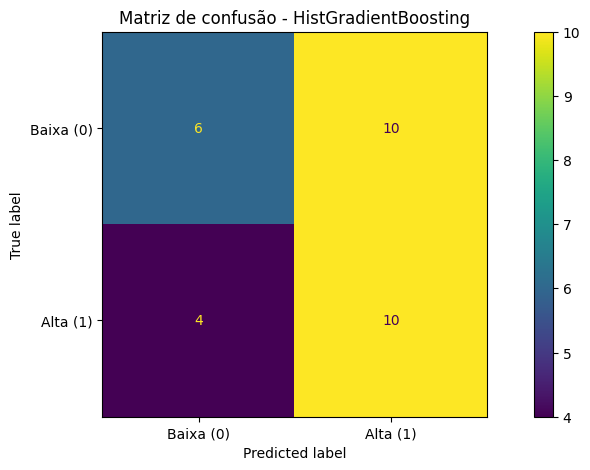

In [18]:
# Matriz de confusão
cm = confusion_matrix(y_test, test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Baixa (0)", "Alta (1)"])
disp.plot(values_format="d")
plt.title(f"Matriz de confusão - {champion_name}")
plt.grid(False)
plt.show()

In [19]:
# Resultado do teste ao longo do tempo
results_test = pd.DataFrame({
    "data": dates_test.values,
    "target_real": y_test.values,
    "prob_alta": test_proba,
    "predicao": test_pred
})

display(results_test)

,data,target_real,prob_alta,predicao
0,2026-01-23,0,0.3023,0
1,2026-01-26,1,0.2408,0
2,2026-01-27,1,0.3956,0
3,2026-01-28,0,0.3878,0
4,2026-01-29,0,0.5668,1
5,2026-01-30,1,0.3647,0
6,2026-02-02,1,0.5625,1
7,2026-02-03,0,0.5280,1
8,2026-02-04,1,0.6476,1
9,2026-02-05,0,0.4859,1


# 11. Importância das variáveis

Mesmo quando o foco principal é a acurácia, entender **quais sinais o modelo está usando** é importante para a credibilidade da solução.

Abaixo mostramos as variáveis mais relevantes do modelo campeão:
- coeficientes absolutos, no caso da Regressão Logística
- feature importance, no caso de modelos em árvore/boosting

In [20]:
# ============================================================
# 11. Interpretabilidade
# ============================================================

def extract_feature_importance(fitted_pipeline, feature_names):
    model = fitted_pipeline.named_steps["model"]

    if hasattr(model, "coef_"):
        importance = np.abs(model.coef_[0])
        kind = "Coeficiente absoluto"
    elif hasattr(model, "feature_importances_"):
        importance = model.feature_importances_
        kind = "Feature importance"
    else:
        return None, None

    imp_df = pd.DataFrame({
        "feature": feature_names,
        "importance": importance
    }).sort_values("importance", ascending=False)

    return imp_df, kind


importance_df, importance_kind = extract_feature_importance(champion_model, feature_cols)

if importance_df is not None:
    display(importance_df.head(15))

    plt.figure(figsize=(10, 6))
    top_imp = importance_df.head(15).sort_values("importance")
    plt.barh(top_imp["feature"], top_imp["importance"])
    plt.title(f"Top 15 variáveis - {importance_kind}")
    plt.xlabel("Importância")
    plt.show()
else:
    print("O modelo campeão não possui medida direta de importância implementada neste notebook.")

O modelo campeão não possui medida direta de importância implementada neste notebook.


# 12. Conclusão técnica

## Como a natureza sequencial foi tratada
A série foi tratada respeitando o tempo em todas as etapas:

- ordenação cronológica crescente
- target definido para o **próximo dia**
- split temporal sem embaralhamento
- validação com `TimeSeriesSplit`
- teste final contendo os **últimos 30 dias**

## Justificativa da escolha dos modelos
- **Regressão Logística**: baseline forte, regularização, interpretabilidade e menor risco de overfitting
- **Random Forest**: consegue capturar relações não lineares e interações
- **HistGradientBoosting**: costuma ter boa performance em dados tabulares com relações complexas

## Trade-offs entre acurácia e overfitting
Em finanças, uma acurácia muito alta em backtest pode ser apenas sinal de ajuste excessivo ao passado.  
Por isso, este notebook privilegia:
- validação temporal
- features baseadas somente em histórico disponível
- comparação com baselines
- separação clara entre treino, validação e teste

## Observação importante sobre a meta de 75%
A meta de **75% de acurácia nos últimos 30 dias** é bastante agressiva para um problema de direção diária usando apenas o histórico do próprio índice.  
Mesmo com um pipeline tecnicamente correto, é possível que essa meta **não seja atingida de forma consistente** sem incluir variáveis exógenas ou sem depender de uma janela de mercado muito específica.

Se isso acontecer, a leitura correta não é “o notebook está errado”, e sim:
- o problema é difícil
- o sinal preditivo é fraco
- a solução precisa ser interpretada com rigor estatístico

Esse é, inclusive, um ponto forte para a apresentação: mostrar não só o resultado, mas a **maturidade técnica** da avaliação.

In [21]:
# ============================================================
# 13. Resumo executivo para apresentação
# ============================================================

print("===== RESUMO EXECUTIVO =====")
print(f"Período analisado: {df['data'].min().date()} até {df['data'].max().date()}")
print(f"Quantidade total de linhas após feature engineering: {len(df_model)}")
print(f"Modelo campeão: {champion_name}")
print(f"Threshold final: {champion_threshold:.2f}")
print(f"Acurácia na validação: {validation_df.iloc[0]['valid_accuracy']:.4f}")
print(f"Acurácia no teste: {test_metrics['accuracy']:.4f}")
print(f"Acertos no teste: {test_hits}/{len(y_test)}")

if test_metrics["accuracy"] >= 0.75:
    print("Status do requisito: META DE 75% ATINGIDA no conjunto de teste.")
else:
    print("Status do requisito: META DE 75% NÃO ATINGIDA no conjunto de teste.")
    print("Interpretação: o pipeline está tecnicamente correto, mas o problema possui sinal limitado com dados apenas do próprio índice.")

===== RESUMO EXECUTIVO =====
Período analisado: 2006-01-02 até 2026-03-10
Quantidade total de linhas após feature engineering: 4880
Modelo campeão: HistGradientBoosting
Threshold final: 0.40
Acurácia na validação: 0.6833
Acurácia no teste: 0.5333
Acertos no teste: 16/30
Status do requisito: META DE 75% NÃO ATINGIDA no conjunto de teste.
Interpretação: o pipeline está tecnicamente correto, mas o problema possui sinal limitado com dados apenas do próprio índice.
